<a href="https://colab.research.google.com/github/fernandolievano/procesamiento-del-habla/blob/main/PDH_TP_1_PROCESAMIENTO_DE_ARCHVOS_PDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROCESAMIENTO DE ARCHIVOS PDF

- Asignatura: Procesamiento del Habla
- Carrera: Inteligencia Artificial y Ciencia de Datos

### Librerías y recursos

In [103]:
!pip install requests pypdf pdfplumber spacy

In [104]:
!python -m spacy download en_core_web_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [124]:
# importación y setup de librerías
import requests
import pandas as pd
import pdfplumber
import spacy
import string
import matplotlib.pyplot as plt
import seaborn as sns

from pypdf import PdfReader
from collections import Counter


In [106]:
# variables globales
pdf_url = 'https://theswissbay.ch/pdf/Gentoomen%20Library/Software%20Engineering/B.W.Kernighan%2C%20R.Pike%20-%20The%20Practice%20of%20Programming.pdf'
pdf_output_filename = 'good_coding_practices.pdf'

In [107]:
# utilities
def print_title(title):
    print(f'{'==='*30}')
    print(f" {title}")
    print(f'{'==='*30} \n')

## 1. Adquisición y metadatos
Descarga del archivo pdf mediante el uso de la librería ```requests``` y visualización de su metadata por medio de la librería ```fitz```



In [108]:
def download_pdf_file(url, filename):
    try:
        response = requests.get(url)
        response.raise_for_status()

        with open(filename, 'wb') as file:
            file.write(response.content)
        print(f"El archivo '{filename}' se ha descargado correctamente.")
    except requests.exceptions.RequestException as e:
        print(f"Error al descargar archivo: {e}")


download_pdf_file(pdf_url, pdf_output_filename)

El archivo 'good_coding_practices.pdf' se ha descargado correctamente.


Testamos y verificamos mediante el comando ```ls``` que el archivo se encuentre descargado

In [109]:
! ls -lh

total 4.9M
-rw-r--r-- 1 root root 4.9M Apr 21 00:55 good_coding_practices.pdf
drwxr-xr-x 1 root root 4.0K Apr 16 13:28 sample_data


Visualizamos su metadata con PdfReader

In [110]:
pdf_file = PdfReader(pdf_output_filename)
pdf_metadata = pdf_file.metadata

print_title(f'METADATOS DE {pdf_output_filename}')

for metadata_key, metadata_value in pdf_metadata.items():
    print(f"ℹ️ {metadata_key}: {metadata_value}")
    print('\n')

 METADATOS DE good_coding_practices.pdf

ℹ️ /ModDate: D:20031201145157+08'00'


ℹ️ /CreationDate: D:20031130132807Z


ℹ️ /Title: DjVu Document


ℹ️ /Creator: Adobe Acrobat 6.01


ℹ️ /Author: Chuan


ℹ️ /Producer: Adobe Acrobat 6.01 Paper Capture Plug-in




## 2. Análisis estructural del texto

- Vamos a extraer el texto de las primeras 5 páginas para visualizarlo de la manera más cruda posible.

- Vamos a observar y describir como están separados los párrafos, secciones y capítulos. Mientras intentamos identificar caracteres especiales como "\n, \r, \t", etc.).

In [111]:
# Usamos pypdf para extraer el texto de las 5 primeras páginas

pdf_file = PdfReader(pdf_output_filename)
number_of_pages_to_extract = 5

for i in range(number_of_pages_to_extract):
    # accedemos a la lista "pages" de nuestra variable "pdf_file" y
    # seleccionamos según el índice correspondiente al ciclo de nuestro loop
    page = pdf_file.pages[i]
    raw_text = page.extract_text() or "[No hay texto disponible]"
    print(f"-> Página {i + 1}: \n")
    # usamos "repr" para ver el texto crudo y que python no
    # renderice los saltos de línea
    print(repr(raw_text))
    print("\n \n")

-> Página 1: 

'[No hay texto disponible]'

 

-> Página 2: 

"Programming/Software Engineering \nThe Practice of Programming \nWith the same insight and authority that made their book The Unix Programming \nEnvironment a classic, Brian Kernighan and Rob Pike have written The Practice \nof Programming to help make individual programmers more effective and \nproductive. \nThe practice of programming is more than just writing code. Programmers must \nalso assess tradeoffs, choose among design alternatives, debug and test, improve \nperformance, and maintain software written by themselves and others. At the \nsame time, they must be concerned with issues like compatibility, robustness, \nand reliability, while meeting specifications. \nThe Practice of Programming covers all these topics, and more. This book is full \nof practical advice and real -world examples in C, C++, lava, and a variety of \nspecial-purpose languages. It includes chapters on: \ndebugging: finding bugs quickly and met

> Vemos que en la primera página no hay texto disponible, y eso se debe a que corresponde a la portada y se ve únicamente una imagen en ella. También notamos que los párrafos y saltos de línea están hechos principalmente por el separador "\n"



## 3. Extracción de datos tabulares

- Vamos a buscar una página en nuestro PDF que contenga una tabla de datos, extraer la tabla y convertirla en un DataFrame de Pandas.
- Realizaremos una limpieza básica de la tabla (nombrar columnas, eliminar filas vacías)
- Se utilizará la librería pdfplumber como recurso

In [112]:
print_title('EXTRACCIÓN DE DATOS TABULARES')

# se buscó manualmente una página con tabla para realizar el ejercicio
selected_page = 96

# abrimos el pdf con "pdfplumber"
with pdfplumber.open(pdf_output_filename) as pdf:
    page_with_potential_table = pdf.pages[selected_page - 1] # -1 porque se inicia el primer índice es 0
    table = page_with_potential_table.extract_tables()[0]

    if table:
        print(f"-> Tabla encontrada en la página {selected_page}: \n")

        print(f"La tabla tiene {len(table)} filas")

        print(f"{table}")
    else:
        print(f"No se encontraron tablas en la página {selected_page}")


 EXTRACCIÓN DE DATOS TABULARES

-> Tabla encontrada en la página 96: 

La tabla tiene 4 filas
[['Symbol', 'Last Trade', None, 'Change', None, 'Volume'], ['LU', '2: 19PM', '86- 114', '+4-1/16', '+4.94%', '5,804,800'], ['T', '2: 19PM', '60-1 1/16', '1-3/16\n-', '- 1.92%', '2,468,000'], ['MSFT', '2:24PM', '106-911 6', '+\n1-318', '+\n1.3 1 %', '1 1,474,900']]


Convertimos la tabla a un Dataframe de ```pandas```

In [113]:
# usamos el parámetro columns=table[0] para indicar que los elementos
# ubicados en el índice 0 corresponden a los encabezados
df_table = pd.DataFrame(table[1:], columns=table[0])
df_table.head()

,Symbol,Last Trade,None,Change,None,Volume
0,LU,2: 19PM,86- 114,+4-1/16,+4.94%,"5,804,800"
1,T,2: 19PM,60-1 1/16,1-3/16\n-,- 1.92%,"2,468,000"
2,MSFT,2:24PM,106-911 6,+\n1-318,+\n1.3 1 %,"1 1,474,900"


Vamos a renombrar las columnas que aparecen como NaN, y vamos a limpiar los values para remover los "\n" que existen

In [114]:
print_title('RENOMBRAMOS COLUMNAS')

df_table.columns = [
    "Symbol",
    "Last Trade (time)",
    "Last Trade (value)",
    "Change",
    "Change (percent)",
    "Volume"
]

df_table.head()

 RENOMBRAMOS COLUMNAS



,Symbol,Last Trade (time),Last Trade (value),Change,Change (percent),Volume
0,LU,2: 19PM,86- 114,+4-1/16,+4.94%,"5,804,800"
1,T,2: 19PM,60-1 1/16,1-3/16\n-,- 1.92%,"2,468,000"
2,MSFT,2:24PM,106-911 6,+\n1-318,+\n1.3 1 %,"1 1,474,900"


In [115]:
print_title('LIMPIEZA DE DATOS, REMOVEMOS LOS SALTOS DE LÍNEA DE LOS VALUES')

df_table = df_table.replace("\n", "", regex=True)
df_table.head()


 LIMPIEZA DE DATOS, REMOVEMOS LOS SALTOS DE LÍNEA DE LOS VALUES



,Symbol,Last Trade (time),Last Trade (value),Change,Change (percent),Volume
0,LU,2: 19PM,86- 114,+4-1/16,+4.94%,"5,804,800"
1,T,2: 19PM,60-1 1/16,1-3/16-,- 1.92%,"2,468,000"
2,MSFT,2:24PM,106-911 6,+1-318,+1.3 1 %,"1 1,474,900"


## 4.  Análisis de frecuencias (NLP básico)

Vamos a elegir una página únicamente con texto narrativo y con ayuda de spacy vamos a realizar tokenización y limpieza eliminando las stopwords.

Luego vamos a generar un gráfico de barras para mostrar las 15 palabras más frecuentes de la página.

In [116]:
print_title('ANALIZAMOS LA PÁGINA 102, Y EXTRAEMOS SU TEXTO')

selected_page = 102

with pdfplumber.open(pdf_output_filename) as pdf:
    page = pdf.pages[selected_page - 1]
    raw_text = page.extract_text()

print(raw_text)

 ANALIZAMOS LA PÁGINA 102, Y EXTRAEMOS SU TEXTO

92 INTERFACES CHAPTER 4
not desirable. We decided to return NULL, the conventional value for a non-existent
string in C.
Information hiding. The library will impose no limits on input line length or number
of fields. To achieve this, either the caller must provide the memory or the callee (the
library) must allocate it. The caller of the library function fgets passes in an array
and a maximum size. If the line is longer than the buffer, it is broken into pieces.
This behavior is unsatisfactory for the CSV interface, so our library will allocate mem-
ory as it discovers that more is needed.
Thus only csvgetl i ne knows about memory management; nothing about the way
that it organizes memory is accessible from outside. The best way to provide that iso-
lation is through a function interface: csvgetl i ne reads the next line, no matter how
big, csvfield(n) returns a pointer to the bytes of the n-th field of the current line,
and csvnf i eld 

Procedemos con la tokenización + la limpieza

In [121]:
nlp = spacy.load("en_core_web_sm")

text = raw_text.lower() # convertimos a minúsculas
doc = nlp(text)
stopwords = nlp.Defaults.stop_words

tokens_clean = [
    token.text
    for token in doc
    if token.text not in stopwords
    and token.text not in string.punctuation
    and token.is_alpha
]

conteo = Counter(tokens_clean)
top_15 = conteo.most_common(15)

print_title(f'15 PALABRAS MÁS UTILIZADAS EN LA PÁGINA {selected_page}.')

for word, count in top_15:
    print(f"{word}: {count}")

 15 PALABRAS MÁS UTILIZADAS EN LA PÁGINA 102.

line: 9
csvgetl: 7
ne: 7
field: 7
library: 6
memory: 6
input: 5
fields: 5
file: 5
return: 4
interface: 4
pointer: 4
user: 4
copy: 4
error: 4


Armamos un gráfico para visualizar las palabras más utilizadas

/tmp/ipykernel_536/473814664.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words, y=freqs, palette=palette)


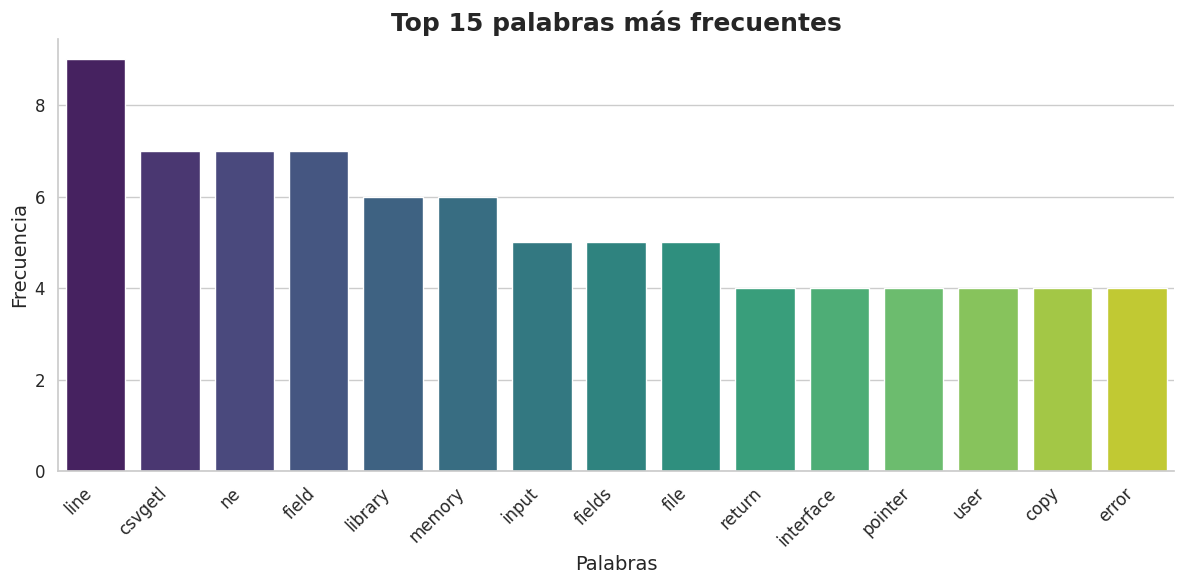

In [129]:
words = [w for w, _ in top_15]
freqs = [f for _, f in top_15]

# styling y setup del gráfico

plt.figure(figsize=(12, 6))

sns.set_theme(style="whitegrid")

palette = sns.color_palette("viridis", len(words))

sns.barplot(x=words, y=freqs, palette=palette)

plt.title("Top 15 palabras más frecuentes", fontsize=18, weight="bold")
plt.xlabel("Palabras", fontsize=14)
plt.ylabel("Frecuencia", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)
sns.despine()

plt.tight_layout()
plt.show()


> En la visualización hay palabras que aunque no sean consideradas stopwords de spacy, en inglés funcionan como si lo fuesen, entre ellas están "just", "even", "still", "also". Es decir, estas palabras mencionadas no aportan contenido semántico al texto y podrían considerarse stopwords.
